Aquí hay un resumen de cómo calcular algunas propiedades clave:

**1. Propiedades Básicas con Pandas y NumPy:**

*   **Tendencia:** Observando visualmente el gráfico de la serie de tiempo, o utilizando promedios móviles (`df['col'].rolling(window=...).mean()`) o regresión lineal.
*   **Estacionalidad:** Inspeccionando visualmente el gráfico o utilizando técnicas como el análisis espectral o la descomposición de la serie de tiempo.
*   **Varianza/Desviación Estándar:** `df['col'].var()` o `df['col'].std()`.
*   **Media:** `df['col'].mean()`.
*   **Correlación/Autocorrelación:**
    *   Correlación entre dos series: `df['col1'].corr(df['col2'])`.
    *   Autocorrelación: La función `pd.Series.autocorr(lag=...)` o `statsmodels.tsa.stattools.acf()`.
    *   Autocorrelación parcial: `statsmodels.tsa.stattools.pacf()`.

**2. Descomposición de Series de Tiempo con Statsmodels:**

La descomposición separa una serie de tiempo en sus componentes observados: tendencia, estacionalidad y residuo.

*   `from statsmodels.tsa.seasonal import seasonal_decompose`
*   `result = seasonal_decompose(data, model='additive')` o `model='multiplicative'`
*   Puedes acceder a los componentes con `result.trend`, `result.seasonal`, `result.resid`.

**3. Pruebas de Estacionariedad con Statsmodels:**

La estacionariedad es una suposición importante para muchos modelos de series de tiempo.

*   **Prueba de Dickey-Fuller Aumentada (ADF):**
    *   `from statsmodels.tsa.stattools import adfuller`
    *   `adfuller(data)`: El p-valor indica si la serie es estacionaria (p-valor bajo).

**4. Modelos de Series de Tiempo (ARIMA, SARIMA) con Statsmodels y pmdarima:**

Estos modelos ayudan a comprender la estructura de la serie de tiempo y a hacer predicciones. Aunque no calculan directamente "propiedades" en el sentido de estadísticas descriptivas, sus parámetros (p, d, q para ARIMA) están relacionados con la autocorrelación y la dependencia en el tiempo.

*   `from statsmodels.tsa.arima.model import ARIMA`
*   `from pmdarima import auto_arima` (para encontrar automáticamente los mejores parámetros).

In [ ]:
import pandas as pd
import numpy as np
from statsmodels.tsa.seasonal import seasonal_decompose
import statsmodels.api as sm

In [ ]:
# Carga de Datos clasica

df = pd.read_csv('ventas-tienda.csv')
df["fecha"] = pd.to_datetime(df["fecha"])
df.set_index('fecha', inplace=True)
df.sort_index(inplace=True)
df.head()

,ventas
fecha,
2023-01-01,62.53
2023-01-02,52.80
2023-01-03,54.87
2023-01-04,58.20
2023-01-05,58.10


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 731 entries, 2023-01-01 to 2024-12-31
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   ventas  731 non-null    float64
dtypes: float64(1)
memory usage: 11.4 KB


<Axes: xlabel='fecha'>

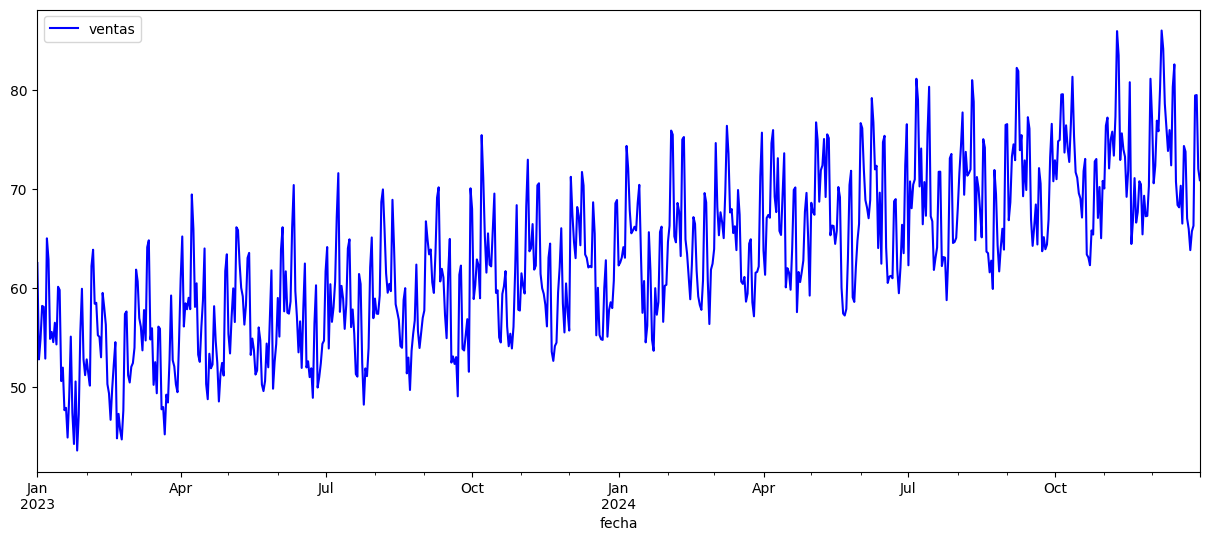

In [ ]:
df.plot(kind='line', figsize=(15, 6), color='blue')


In [ ]:
freq = pd.infer_freq(df.index)
print(freq)

D


<Axes: xlabel='fecha'>

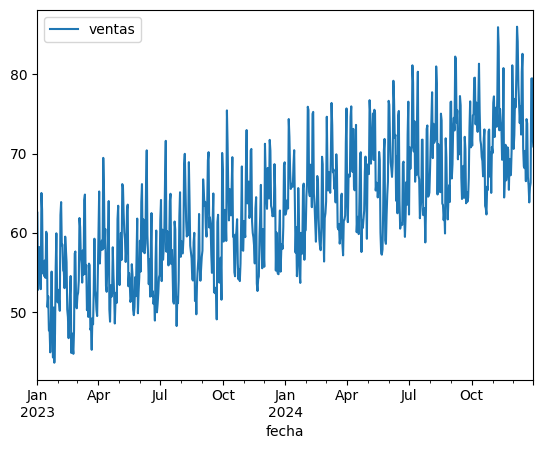

In [ ]:
# --- Metodo 1: Visual ---
df.plot()

In [ ]:
# --- Método 2: Regresión Lineal ---
# Ajusta una línea recta a los datos para representar la tendencia lineal.
X = np.arange(len(df)).reshape(-1, 1)
y = df['ventas'].values
model = sm.OLS(y, sm.add_constant(X)).fit()
df['linear_trend'] = model.predict(sm.add_constant(X))

print("\nTendencia calculada con Regresión Lineal:")
print(df[['ventas', 'linear_trend']].head())


Tendencia calculada con Regresión Lineal:
            ventas  linear_trend
fecha                           
2023-01-01   62.53     52.594594
2023-01-02   52.80     52.623400
2023-01-03   54.87     52.652205
2023-01-04   58.20     52.681010
2023-01-05   58.10     52.709816


<Axes: xlabel='fecha'>

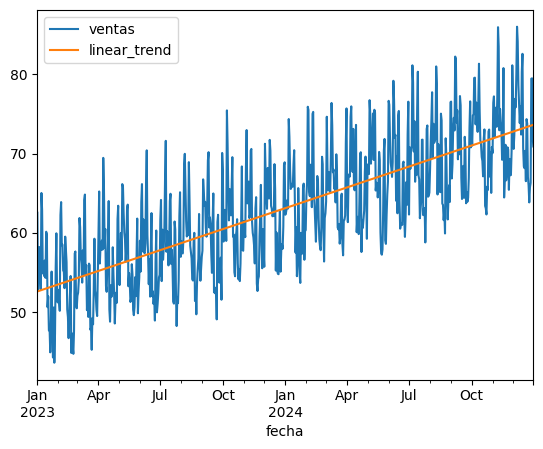

In [ ]:
df.plot()

## Recordemos los modelos de descomposición
### Aditivo o Multiplicativo?
### Veamos...

Modelos
Aditivo:

𝑌
𝑡
=
𝑇
𝑡
+
𝑆
𝑡
+
𝑅
𝑡

Aquí la magnitud de la estacionalidad y del ruido es independiente del nivel de la serie: los “picos” y “valles” tienen amplitud constante.

Multiplicativo:

𝑌
𝑡
=
𝑇
𝑡
×
𝑆
𝑡
×
𝑅
𝑡

En este caso la estacionalidad y el ruido se escalan con la tendencia. A medida que Tₜ crece, también lo hace la amplitud de Sₜ y de Rₜ.




Criterios visuales
Amplitud constante vs. proporcional

Si las oscilaciones (picos/caídas) tienen aproximadamente la misma altura a lo largo de toda la serie ⇒ aditivo.

Si crecen o disminuyen proporcionalmente al nivel de la serie ⇒ multiplicativo.

Transformación logarítmica

Aplica
𝑌
𝑡
′
=
ln
⁡
(
𝑌
𝑡
)

Si tras el logaritmo la serie se ve “más” aditiva (oscilaciones de amplitud constante), entonces el modelo original era multiplicativo.

Descompón la serie en ambos modelos (additive y multiplicative) con una función como seasonal_decompose.

Compara el error (por ejemplo SSE o RSS) de los residuos en cada caso:

RSS
=
∑
𝑡
(
𝑅
𝑡
)
2

El modelo que arroje menor RSS proporciona un mejor ajuste.

In [ ]:
import numpy as np
from statsmodels.tsa.seasonal import seasonal_decompose

# 1. Extrae la serie
serie = df['ventas']

# 2. Define el periodo de estacionalidad (ajusta según tu serie: 7 para semanal, 30/31 mensual, 365 anual)

period = 30 # es el periodo aproximado que se observa

# 3. Descomposición en modo aditivo y multiplicativo
decomp_add = seasonal_decompose(serie, model='additive', period=period)
decomp_mul = seasonal_decompose(serie, model='multiplicative', period=period)

# 4. Calcula el RSS (suma de residuos al cuadrado) para cada modelo
rss_add = np.nansum(decomp_add.resid**2)
rss_mul = np.nansum(decomp_mul.resid**2)

print(f"RSS aditivo:        {rss_add:.2f}")
print(f"RSS multiplicativo: {rss_mul:.2f}")

# 5. Elige el que mejor ajusta (menor RSS)
if rss_mul < rss_add:
    print("Mejor modelo: multiplicativo")
else:
    print("Mejor modelo: aditivo")

RSS aditivo:        14139.51
RSS multiplicativo: 704.37
Mejor modelo: multiplicativo


## Ojo...
### Residuos en el multiplicativo
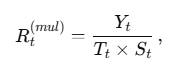
### Residuos en el aditivo
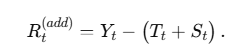

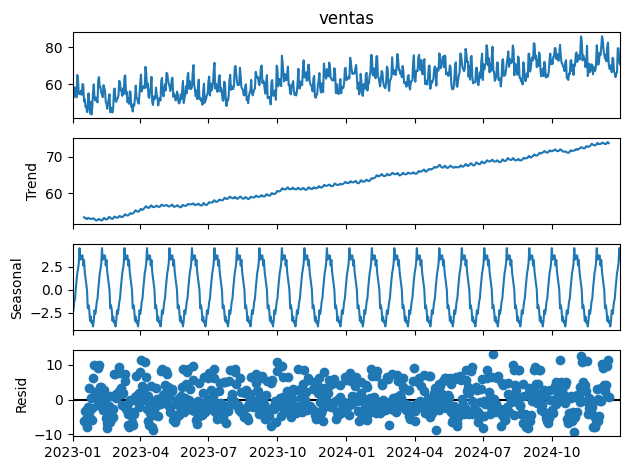

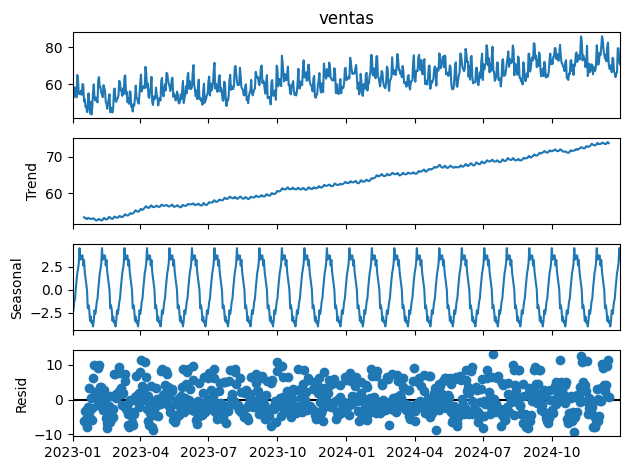

In [ ]:
decomp_add.plot()

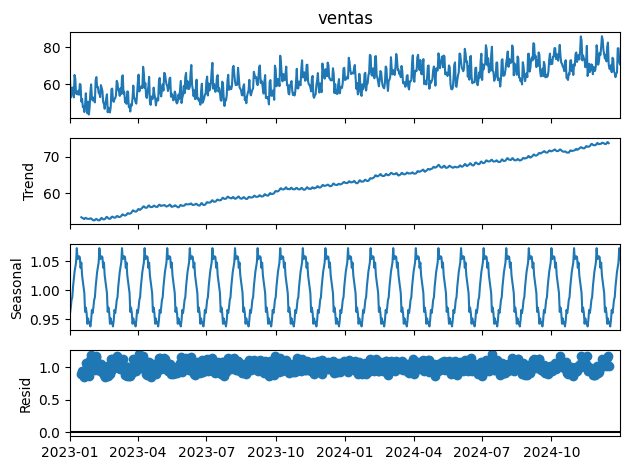

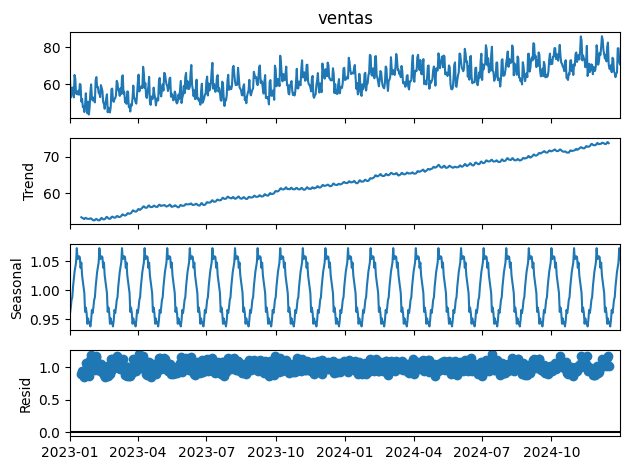

In [ ]:
decomp_mul.plot()

In [ ]:
# ya tenemos decomp_add y decomp_mul de seasonal_decompose

# Reconstrucción aditiva
yhat_add = decomp_add.trend + decomp_add.seasonal

# Reconstrucción multiplicativa
yhat_mul = decomp_mul.trend * decomp_mul.seasonal


In [ ]:
# Serie original
y = serie.values

# Asegúrate de alinear índices y tirar NaN
mask = ~np.isnan(yhat_add) & ~np.isnan(yhat_mul)
y0 = y[mask]
yhat0_add = yhat_add[mask]
yhat0_mul = yhat_mul[mask]

# Suma de cuadrados de errores (RSS) sobre la misma escala
rss_add_corrected = np.sum((y0 - yhat0_add)**2)
rss_mul_corrected = np.sum((y0 - yhat0_mul)**2)

print(f"RSS Aditivo (reconstrucción):        {rss_add_corrected:.2f}")
print(f"RSS Multiplicativo (reconstrucción): {rss_mul_corrected:.2f}")

if rss_mul_corrected < rss_add_corrected:
    print("Mejor modelo (por RSS en escala original): multiplicativo")
else:
    print("Mejor modelo (por RSS en escala original): aditivo")

RSS Aditivo (reconstrucción):        14139.51
RSS Multiplicativo (reconstrucción): 14280.04
Mejor modelo (por RSS en escala original): aditivo


## Por esa razon debemos transformar o trabajar de forma logaritmica

Recuerden que el atributo period hace referencia siempre a a la frecuencia de la serie en conjunto con la estacionalidad esperada:
- Semana: 7
- Mes: 30
- Año: 365

Internamente, seasonal_decompose utiliza ese valor para:

Extraer la tendencia con un suavizado de ventana bidireccional de tamaño ≈ 2*period+1.

Aislar la componente estacional promediando los residuos alrededor de cada posición del ciclo.

Calcular los residuales como la diferencia (additive) o el cociente (multiplicative) entre la serie original y la suma/producto de los dos componentes anteriores.

Si no proporcionamos period y tu índice tiene un atributo freq (por ejemplo freq='M' para mensual), seasonal_decompose intentará inferirlo automáticamente de esa frecuencia.

In [ ]:
# --- Método 3: Descomposición de Series de Tiempo ---
# Descompone la serie en tendencia, estacionalidad y residuo.
# 'model' puede ser 'additive' o 'multiplicative' dependiendo de si los componentes se suman o se multiplican.
# 'period' es el número de períodos en cada ciclo estacional (ej: 12 para datos mensuales con estacionalidad anual).
# En este caso dijimos aditivo con periodo de 30.

import pandas as pd
from statsmodels.tsa.seasonal import seasonal_decompose

# 1. Asegurar que el índice sea datetime
if not isinstance(df.index, pd.DatetimeIndex):
    df.index = pd.to_datetime(df.index)

# 2. Descomponer la serie (aditivo con ciclo ≈ mensual)
decomp = seasonal_decompose(df['ventas'], model='additive', period=30)

# 3. Guardar componentes en el DataFrame
df['trend']    = decomp.trend
df['seasonal'] = decomp.seasonal
df['residual'] = decomp.resid

# 4. Mostrar los primeros resultados
print(df[['ventas','trend','seasonal','residual']].head())

            ventas  trend  seasonal  residual
fecha                                        
2023-01-01   62.53    NaN -2.651258       NaN
2023-01-02   52.80    NaN -2.115547       NaN
2023-01-03   54.87    NaN -1.313584       NaN
2023-01-04   58.20    NaN -0.989207       NaN
2023-01-05   58.10    NaN  0.069366       NaN


### Aca un poco mas largo...

In [ ]:
def determinar_modelo_serie(df, columna_valor, period):
    """
    Determina si una serie de tiempo sigue un modelo aditivo o multiplicativo
    basándose en la variabilidad de la estacionalidad.

    Args:
        df (pd.DataFrame): DataFrame con la serie de tiempo.
        columna_valor (str): Nombre de la columna que contiene los valores de la serie.
        period (int): El número de períodos en cada ciclo estacional.

    Returns:
        str: 'additive' si la estacionalidad parece constante,
             'multiplicative' si la estacionalidad parece aumentar con la tendencia.
    """
    try:
        # Intenta la descomposición aditiva
        result_additive = seasonal_decompose(df[columna_valor], model='additive', period=period)
        # Intenta la descomposición multiplicativa
        result_multiplicative = seasonal_decompose(df[columna_valor], model='multiplicative', period=period)

        # Analizar la variabilidad de la estacionalidad en relación con la tendencia
        # Si la magnitud de los residuos aditivos aumenta con la tendencia,
        # el modelo multiplicativo es más probable.
        # Si la magnitud de los residuos multiplicativos es más constante,
        # el modelo multiplicativo es más probable.

        # Opción 1: Comparar la varianza de los residuos
        # En un modelo aditivo adecuado, los residuos deberían tener una varianza más constante.
        # En un modelo multiplicativo adecuado, los residuos (después de dividir por la tendencia*estacionalidad)
        # deberían tener una varianza más constante.
        # Comparar la varianza de los residuos aditivos vs. la varianza de los residuos multiplicativos (normalizados)
        # Esto puede ser un poco sensible a outliers.

        # Opción 2: Visualizar y comparar los componentes estacionales
        # En un modelo aditivo, el componente estacional tiene una amplitud relativamente constante a lo largo del tiempo.
        # En un modelo multiplicativo, el componente estacional (como proporción de la tendencia)
        # tiene una amplitud relativamente constante, lo que significa que su valor absoluto
        # aumenta o disminuye con la tendencia.

        # Un enfoque práctico es comparar la varianza del componente estacional absoluto
        # frente a la varianza del componente estacional relativo (para el modelo multiplicativo).
        # Un modelo aditivo sugiere que la varianza del componente estacional aditivo es relativamente constante.
        # Un modelo multiplicativo sugiere que la varianza del componente estacional
        # dividido por la tendencia (aproximadamente) es relativamente constante.

        # Calcule la desviación estándar del componente estacional para ambos modelos.
        # Ignore los NaNs resultantes de la descomposición.
        std_seasonal_additive = result_additive.seasonal.dropna().std()
        # Para el modelo multiplicativo, el componente estacional representa un factor.
        # Podemos analizar la varianza del componente estacional multiplicativo en sí.
        std_seasonal_multiplicative = result_multiplicative.seasonal.dropna().std()

        # Otra forma de pensar es: en el modelo aditivo, la variabilidad de la estacionalidad
        # es independiente del nivel de la serie. En el modelo multiplicativo, la variabilidad
        # es proporcional al nivel.
        # Podemos examinar la relación entre el valor de la serie original y el valor absoluto del componente estacional aditivo.
        # Si esta relación es más constante, el modelo multiplicativo es mejor.

        # Vamos a comparar la varianza de los residuos. En un modelo aditivo, los residuos deben ser aleatorios y con varianza constante.
        # En un modelo multiplicativo, los residuos (que son lo que queda después de dividir) deben ser aleatorios y con varianza constante.
        # Por lo tanto, si la varianza de los residuos aditivos es mucho mayor cuando la serie es alta, y menor cuando es baja,
        # sugiere un modelo multiplicativo. Si la varianza de los residuos aditivos es relativamente constante, sugiere un modelo aditivo.

        # Calcular la varianza de los residuos aditivos
        var_resid_additive = result_additive.resid.dropna().var()

        # Para el modelo multiplicativo, los residuos son el factor restante.
        # Podemos mirar la varianza de los residuos multiplicativos.
        var_resid_multiplicative = result_multiplicative.resid.dropna().var()

        print(f"Varianza de los residuos (Aditivo): {var_resid_additive}")
        print(f"Varianza de los residuos (Multiplicativo): {var_resid_multiplicative}")

        # Un criterio común es elegir el modelo cuyos residuos tengan la menor varianza.
        # Sin embargo, esto no siempre es el mejor indicador si las escalas son muy diferentes.
        # Otro enfoque es ver cómo la amplitud del componente estacional cambia con la tendencia.

        # Una heurística: Si la varianza del componente estacional (aditivo) parece aumentar con la tendencia,
        # es probable que sea multiplicativo.
        # Una forma de aproximar esto es comparar la desviación estándar del componente estacional
        # en diferentes segmentos de la serie (ej. principio vs. fin si hay una tendencia clara).

        # Otra heurística simple: si la desviación estándar del componente estacional multiplicativo
        # (que es un factor) es significativamente menor que la desviación estándar del componente
        # estacional aditivo (que es un valor absoluto), puede sugerir un modelo multiplicativo
        # porque el factor estacional es más constante que el valor absoluto del componente estacional.

        if std_seasonal_multiplicative < std_seasonal_additive: # Este es un heurística, no una regla estricta
             print("\nSegún la heurística de la desviación estándar del componente estacional:")
             print("La desviación estándar del componente estacional multiplicativo es menor.")
             return 'multiplicative'
        else:
             print("\nSegún la heurística de la desviación estándar del componente estacional:")
             print("La desviación estándar del componente estacional aditivo es menor o similar.")
             return 'additive'

        # También podrías visualizar los residuos de ambos modelos y ver cuál parece más aleatorio
        # y con varianza constante a lo largo del tiempo.

    except Exception as e:
        print(f"Error durante la descomposición: {e}")
        print("No se pudo determinar el modelo automáticamente.")
        return None

# Asegúrate de que la columna 'value' existe en tu DataFrame y que tiene la frecuencia adecuada
# Ejemplo: Si tu serie es mensual, period=12. Si es diaria con estacionalidad semanal, period=7.
# Reemplaza 'value' con el nombre real de tu columna de datos si es diferente.
# Reemplaza 'period' con la frecuencia de tu serie de tiempo.

# **Usando la función con tu DataFrame 'df' y la columna 'ventas'**
# Primero, asegúrate de que tu DataFrame tenga un DatetimeIndex y que hayas cargado los datos correctamente.
# Supongamos que tu DataFrame 'df' ya está cargado y tiene la columna 'ventas'
# como se muestra en tu código previo.

# Determinar la frecuencia de la serie. Si es regular, pd.infer_freq es útil.
# Si no, necesitas saber el período de estacionalidad manualmente.
# Por ejemplo, si sabes que es estacionalidad anual en datos mensuales, el período es 12.
# Si es estacionalidad diaria en datos por hora, el período es 24.

# Asegúrate de que df.index es un DatetimeIndex
if not isinstance(df.index, pd.DatetimeIndex):
    df.index = pd.to_datetime(df.index)

# Intenta inferir la frecuencia si no la conoces
inferred_freq = pd.infer_freq(df.index)
print(f"\nFrecuencia inferida: {inferred_freq}")

# Debes conocer el 'period' correcto para la estacionalidad de tu serie.
# Ejemplo: Si sabes que tu estacionalidad es anual y tus datos son mensuales, period = 12.
# Si inferred_freq es 'MS' (Monthly Start), y sabes que la estacionalidad es anual, period = 12.
# Si inferred_freq es 'D' (Daily), y sabes que la estacionalidad es semanal, period = 7.
# Si inferred_freq es 'H' (Hourly), y sabes que la estacionalidad es diaria, period = 24.

# **Necesitas reemplazar `tu_periodo_de_estacionalidad` con el número adecuado**
# Basado en tu código original, parece que tienes datos mensuales ('ventas-tienda.csv')
# y una estacionalidad anual es común para ventas. Por lo tanto, un período de 12 es probable.
tu_periodo_de_estacionalidad = 12 # Ajusta este valor según tu serie de tiempo

# Llama a la función para determinar el modelo
modelo_sugerido = determinar_modelo_serie(df, 'ventas', tu_periodo_de_estacionalidad)

if modelo_sugerido:
    print(f"\nEl modelo sugerido para la serie de tiempo es: {modelo_sugerido}")

    # **Opcional: Visualizar la descomposición con el modelo sugerido**
    try:
        decomposition_final = seasonal_decompose(df['ventas'], model=modelo_sugerido, period=tu_periodo_de_estacionalidad)
        fig = decomposition_final.plot()
        fig.set_size_inches(10, 8)
        plt.suptitle(f'Descomposición de la Serie de Tiempo ({modelo_sugerido} Model)', y=1.02)
        plt.show()

        # Opcional: Graficar los residuos para evaluar visualmente la aleatoriedad
        plt.figure(figsize=(12, 4))
        plt.plot(decomposition_final.resid.dropna())
        plt.title(f'Residuos de la Descomposición ({modelo_sugerido} Model)')
        plt.ylabel('Residuos')
        plt.xlabel('Fecha')
        plt.grid(True)
        plt.show()

    except Exception as e:
        print(f"Error al graficar la descomposición con el modelo sugerido: {e}")

## Calculo de Estacionalidad

In [ ]:
# Descomposición con el modelo sugerido
decomposition_final = seasonal_decompose(df['ventas'], model='additive', period=30)

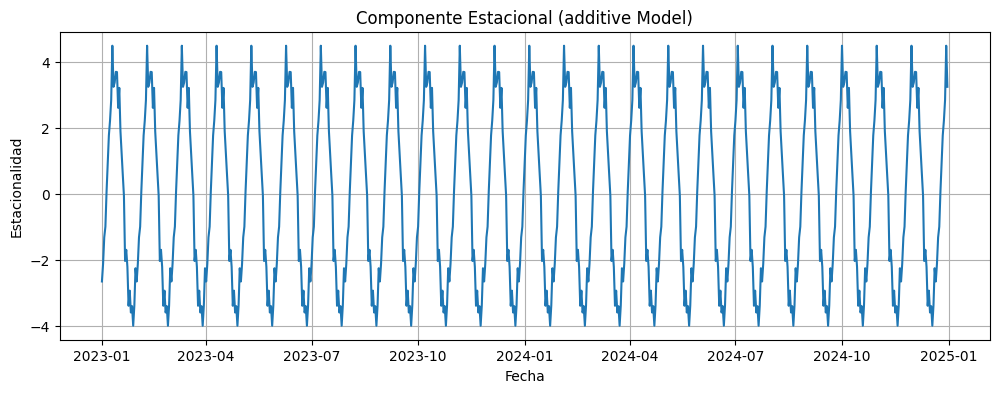

In [ ]:
# Graficar solo el componente estacional
plt.figure(figsize=(12, 4))
plt.plot(decomposition_final.seasonal)
plt.title(f'Componente Estacional (additive Model)')
plt.ylabel('Estacionalidad')
plt.xlabel('Fecha')
plt.grid(True)
plt.show()

### Metodo 2, mas manual, menos ortodoxo, pero practico igual
calcular un índice estacional a partir del promedio de cada posición en el ciclo

In [ ]:
# 1. Supongamos que df ya tiene índice datetime y columna 'ventas'
serie = df['ventas']

# 2. Crear variable que indica día de la semana (0=Lun … 6=Dom)
df['dow'] = serie.index.dayofweek

# 3. Calcular el promedio de ventas por cada día de la semana
#    → este será nuestro patrón estacional “promedio”
seasonal_index = df.groupby('dow')['ventas'].mean()

# 4. Mapear ese índice de vuelta a la serie completa
df['seasonality'] = df['dow'].map(seasonal_index)

# 5. (Opcional) Restar la media general para centrarlo si quieres un modelo aditivo
df['seasonality_centered'] = df['seasonality'] - serie.mean()

print("Índice estacional (promedio por día de la semana):")
print(seasonal_index)
print("\nPrimeros valores de la serie con su componente estacional:")
print(df[['ventas','seasonality','seasonality_centered']].head())

Índice estacional (promedio por día de la semana):
dow
0    60.863238
1    60.957524
2    60.798173
3    60.877885
4    60.820577
5    68.448558
6    68.979524
Name: ventas, dtype: float64

Primeros valores de la serie con su componente estacional:
            ventas  seasonality  seasonality_centered
fecha                                                
2023-01-01   62.53    68.979524              5.871001
2023-01-02   52.80    60.863238             -2.245284
2023-01-03   54.87    60.957524             -2.150999
2023-01-04   58.20    60.798173             -2.310349
2023-01-05   58.10    60.877885             -2.230638


## Calculo de Estacionariedad

<Axes: xlabel='fecha'>

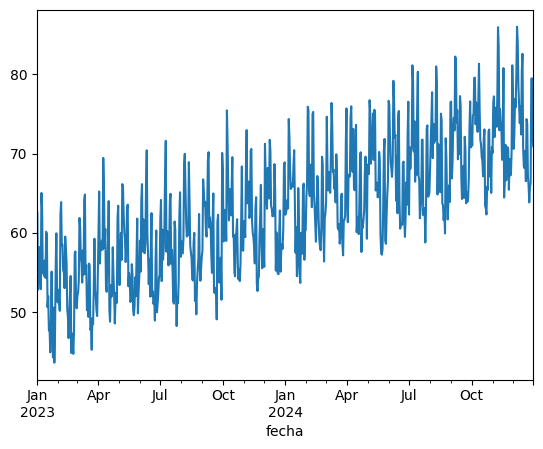

In [ ]:
# Método 1: Inspección Visual (ya se ha hecho con df.plot())
df.ventas.plot()


# Pruebas de Estacionariedad: ADF y KPSS

Para verificar si una serie temporal es **estacionaria**, usamos dos pruebas complementarias:

---

## 1. Augmented Dickey–Fuller (ADF)

- **Objetivo**: detectar si existe raíz unitaria (tendencia) en la serie.  
- **Hipótesis nula (H₀)**: la serie **no es estacionaria** (tiene raíz unitaria).  
- **Interpretación**:  
  - Si **p-value < 0.05** → rechazamos H₀ → la serie **es estacionaria**.  
  - Si **p-value ≥ 0.05** → no rechazamos H₀ → la serie **no es estacionaria**.

---

## 2. Kwiatkowski–Phillips–Schmidt–Shin (KPSS)

- **Objetivo**: comprobar si hay tendencia estacionaria o deriva.  
- **Hipótesis nula (H₀)**: la serie **es estacionaria** (o estacionaria alrededor de una constante).  
- **Interpretación**:  
  - Si **p-value < 0.05** → rechazamos H₀ → la serie **no es estacionaria**.  
  - Si **p-value ≥ 0.05** → no rechazamos H₀ → la serie **es estacionaria**.

---

## 3. ¿Por qué usar ambas?

- **ADF** y **KPSS** tienen hipótesis opuestas:  
  - ADF asume por defecto **no estacionariedad**.  
  - KPSS asume por defecto **estacionariedad**.  
- **Conclusión robusta**:  
  - Si **ADF rechaza H₀** (_estacionaria_) **y** **KPSS no rechaza H₀** (_estacionaria_), confirmamos estacionariedad.  
  - Si **ambas rechazan H₀**, la serie es *claramente no estacionaria*.  
  - Si los resultados difieren, puede requerirse una inspección adicional (diferenciar la serie o examinar tendencias).

---

> 📌 **Nota**: Siempre grafica tu serie y revisa ACF/PACF antes y después de diferenciar para validar visualmente la estacionariedad.

ADF Test
  Estadístico = -0.7295
  p-value     = 0.8390
  Valores críticos:
    1%: -3.4396
    5%: -2.8656
    10%: -2.5689

KPSS Test
  Estadístico = 3.8893
  p-value     = 0.0100
  Valores críticos:
    10%: 0.3470
    5%: 0.4630
    2.5%: 0.5740
    1%: 0.7390

Ratio diario (serie_t / serie_{t-1}) – descripción:
count    730.000000
mean       1.003460
std        0.081421
min        0.786250
25%        0.958098
50%        1.000612
75%        1.050928
max        1.359263
Name: ventas, dtype: float64


<ipython-input-59-2096049053>:19: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, kpss_p, kpss_lags, kpss_crit = kpss(serie, regression='c')


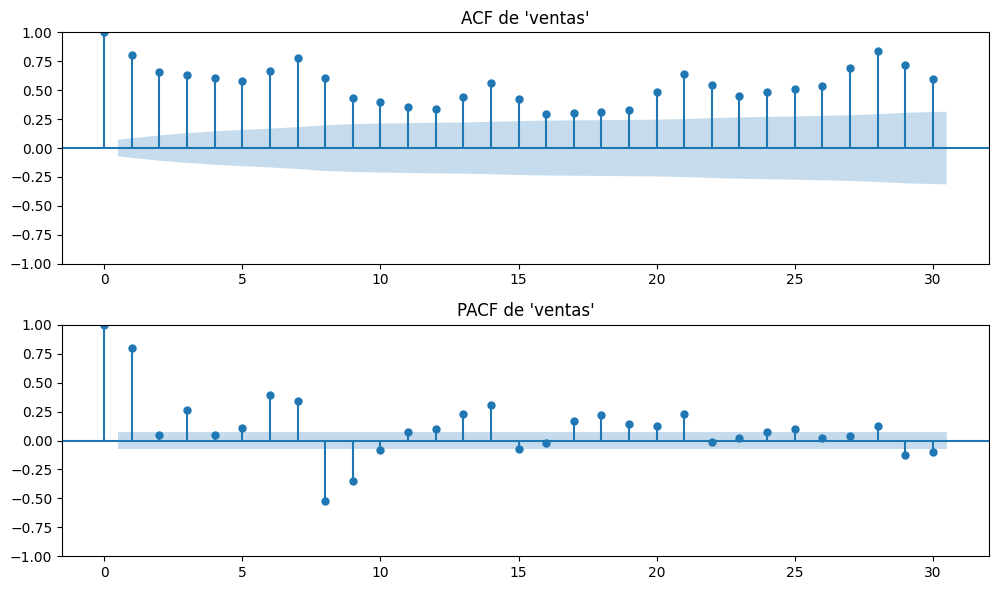

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

serie = df['ventas'].dropna()

# 1. Augmented Dickey–Fuller (ADF) test
adf_stat, adf_p, _, _, adf_crit, _ = adfuller(serie)
print("ADF Test")
print(f"  Estadístico = {adf_stat:.4f}")
print(f"  p-value     = {adf_p:.4f}")
print("  Valores críticos:")
for nivel, val in adf_crit.items():
    print(f"    {nivel}: {val:.4f}")

# 2. KPSS test
# regression='c' prueba estacionariedad alrededor de una constante
kpss_stat, kpss_p, kpss_lags, kpss_crit = kpss(serie, regression='c')
print("\nKPSS Test")
print(f"  Estadístico = {kpss_stat:.4f}")
print(f"  p-value     = {kpss_p:.4f}")
print("  Valores críticos:")
for nivel, val in kpss_crit.items():
    print(f"    {nivel}: {val:.4f}")

# 3. Técnica manual: ratios día a día
ratio = serie / serie.shift(1)
print("\nRatio diario (serie_t / serie_{t-1}) – descripción:")
print(ratio.dropna().describe())

# 4. Gráficos de ACF y PACF
fig, axes = plt.subplots(2, 1, figsize=(10, 6))
plot_acf(serie, lags=30, ax=axes[0], title="ACF de 'ventas'")
plot_pacf(serie, lags=30, ax=axes[1], title="PACF de 'ventas'")
plt.tight_layout()
plt.show()

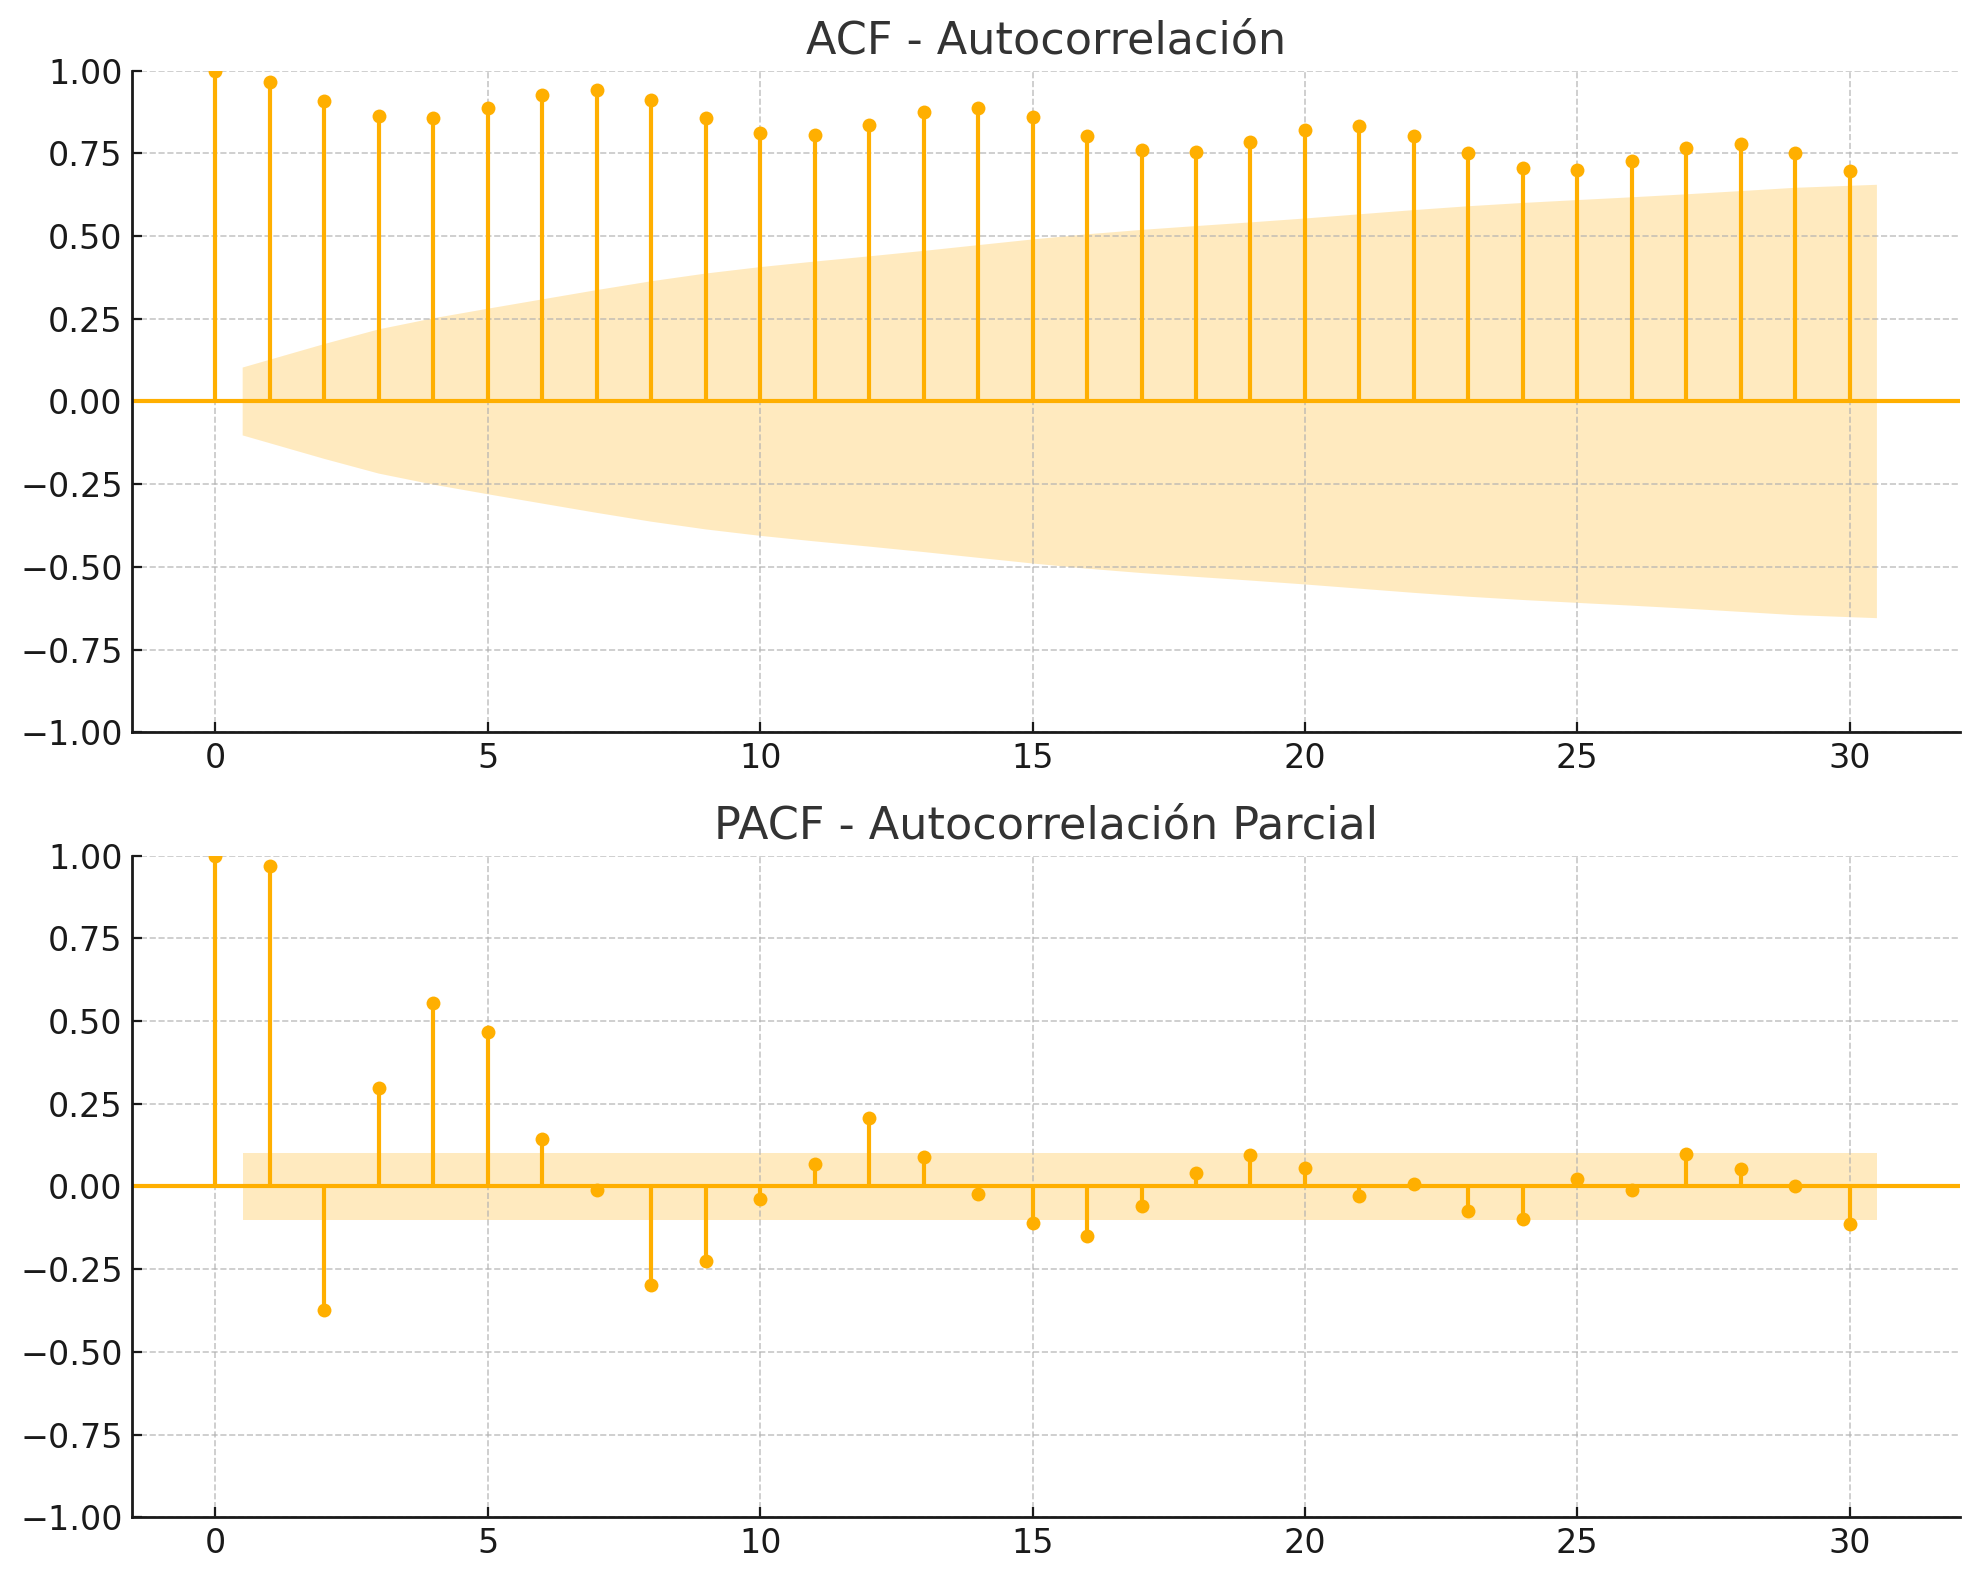

# Interpretación de ACF y PACF

En este bloque encontrarás las claves para interpretar correctamente los gráficos de **ACF** (Autocorrelation Function) y **PACF** (Partial Autocorrelation Function) y utilizarlos al diseñar modelos ARIMA/ARMA.

---

## 1. ACF (Función de Autocorrelación)

- **Qué mide**: correlación entre la serie y sus retardos (lags).
- **Banda de confianza**: líneas punteadas (~95 %). Barras fuera de esa banda son estadísticamente significativas.
- **Tendencia**:
  - **Caída lenta** (“cola larga”) → posible tendencia o no estacionariedad.
- **Estacionalidad**:
  - Picos en lags iguales al período (e.g., lag 7, 14 → semanal; lag 30 → mensual; lag 365 → anual).

---

## 2. PACF (Función de Autocorrelación Parcial)

- **Qué mide**: correlación entre la serie y lag _j_, eliminando efectos de todos los lags intermedios (1…j−1).
- **Orden AR(p)**:
  - El primer lag _j_ que **corte** (barra fuera de la banda) sugiere el orden _p_ en un AR(p).
  - Posteriormente, los lags suelen quedar dentro de la banda.

---

## 3. Cómo elegir el modelo

| Patrón en ACF/PACF                   | Modelo sugerido     |
|--------------------------------------|---------------------|
| ACF decae lento; PACF corta rápido   | AR(p)               |
| PACF decae lento; ACF corta rápido   | MA(q)               |
| Ambos decaen lento                   | ARMA(p,q) o diferenciar antes (serie no estacionaria) |

---

## 4. Resumen práctico

1. **Mira la ACF**  
   - Cola lenta → diferencia o ARMA.  
   - Picos estacionales → incluye componente estacional.

2. **Mira la PACF**  
   - Primer corte → orden _p_ de AR(p).

3. **Decisión**  
   - ACF corta rápido → MA(q).  
   - PACF corta rápido → AR(p).  
   - Ambos mezclados → ARMA(p,q) o diferenciar primero.

---

> ⚠️ **Nota**: Si la serie no es estacionaria (p-value ADF > 0.05), diferénciala antes de confiar en ACF/PACF para elegir _p_ y _q_.  

# Cómo usar ACF y PACF para identificar la estacionariedad

Cuando trabajamos con series temporales, es clave saber si nuestra serie es estacionaria (media y varianza constantes en el tiempo). ACF y PACF nos dan pistas visuales y cuantitativas:

---

## 1. ACF (Función de Autocorrelación)

- **¿Qué muestra?**  
  Correlación entre la serie y sus versiones retrasadas (lags).  
- **Estacionariedad**:  
  - **Cola larga** (la ACF decae lentamente) → la serie **no** es estacionaria.  
  - **Caída rápida** (la ACF corta tras 1 o pocos lags) → indica estacionariedad.  
- **Estacionalidad**:  
  Picos significativos en lags iguales al ciclo (e.g. 7, 14 → semanal; 30 → mensual).

---

## 2. PACF (Función de Autocorrelación Parcial)

- **¿Qué muestra?**  
  Correlación entre la serie y su lag _j_, eliminando la influencia de lags intermedios.  
- **Estacionariedad**:  
  - Un **primer corte** brusco (lag _p_ significativo, luego dentro de la banda) sugiere que un modelo AR(p) podría ser apropiado.  
  - Si no hay corte claro y la PACF decae lentamente, la serie probablemente **no** es estacionaria.

---

## 3. Pasos prácticos

1. **Grafica la ACF** y verifica qué tan rápido decae hacia cero.  
2. **Grafica la PACF** y localiza el primer lag significativo fuera de la banda de confianza.  
3. **Interpreta**:  
   - ACF corta rápido → la serie es estacionaria en nivel.  
   - ACF decae lento → se necesita diferencia (serie no estacionaria).  
   - PACF primer corte en lag p → posible AR(p).

---

> **Tip:** Si la serie no es estacionaria, aplica `.diff()` (primera diferencia) y vuelve a graficar ACF/PACF para confirmar que se ha “aplanado” la cola.

```python
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Ejemplo en Colab: suponer 'serie' es un pd.Series con índice datetime
plot_acf(serie.diff().dropna(), lags=30, title="ACF de la serie diferenciada")
plot_pacf(serie.diff().dropna(), lags=30, title="PACF de la serie diferenciada")
